# Supplementary Material S1.4: Activation-Function Analysis

This notebook reproduces the Case I activation-function panels shown in Supplementary Material S1.4 of the paper. Following the case-notebook workflow, it sweeps the activation function used by the BINN density and diffusion networks and compares the resulting validation-loss and diffusion diagnostics across `silu`, `tanh`, and `sigmoid`.

The notebook contains:

1. Loading and verification of the Case I dataset used throughout the analysis.
2. A catalogue of the compatible BINN checkpoints for each activation-function setting, together with the helper functions for loading the trained wrappers and the shared plotting style.
3. An activation-function sweep that generates the validation-loss, data-loss, diffusion-error, and diffusion-across-epochs panels for each activation.

*It produces Fig. S6 in the supplementary material.*


In [2]:
import os
import sys
from pathlib import Path

import numpy as np
from IPython.display import display

PROJECT_ROOT = next(
    path
    for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "Training").is_dir()
)
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

from Training.JN.notebook_helpers.notebook_data import build_catalog, load_data_object, load_original_data
from Training.JN.notebook_helpers.notebook_models import (
    active_constraint_settings,
    build_model_catalog,
    build_model_path,
    filter_model_catalog,
    load_requested_models,
    summarize_requested_models,
)
from Training.JN.notebook_helpers.notebook_setup import bootstrap_notebook, register_notebook_pickle_globals

paths = bootstrap_notebook(PROJECT_ROOT)
PROJECT_ROOT = paths.project_root
JN_ROOT = paths.notebook_root
DATA_ROOT = paths.data_root
BINN_ROOT = paths.binn_root

register_notebook_pickle_globals()

data_orig_obj_FKPP = load_original_data(DATA_ROOT)

from paper_helpers import (
    scale_function_by_percent_error,
    plot_diffusion_across_epochs,
    plot_final_loss_lst,
    plot_initial_condition_1d,
    plot_running_min_MSE_diff_loss_broken_x_log_lst,
    plot_running_min_loss_component_broken_x_log_lst,
)


## 1. Load the Case I data

We first recover the simulated reaction-diffusion dataset used throughout the notebook. The spatial and temporal grids follow [Lagergren et al. (2020)](https://doi.org/10.1371/journal.pcbi.1008462), and the cell below verifies that the Case I data object exists on disk before any model analysis begins.


MSE between u and u_clean: 0.0
ABS between u and u_clean [cells]: 0.0
ABS (%) between u and u_clean: 0.0


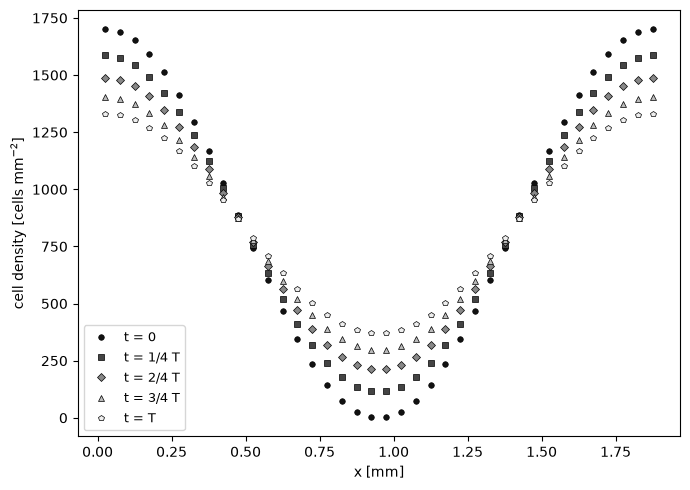

In [3]:
x = data_orig_obj_FKPP.x
t = data_orig_obj_FKPP.t
K = 1

CASE1_DATA_CONFIG = {
    "dataX1num": len(x),
    "dataX2num": 1,
    "dataTnum": len(t),
    "dataK": K,
    "dataICLabel": "cos",
    "dataDiffLabel": "const",
    "dataGrowLabel": "zero",
    "dataGamma": 0,
    "dataNoisePercent": 0,
    "dataNoiseSeed": 0,
}

xNum = CASE1_DATA_CONFIG["dataX1num"]
tNum = CASE1_DATA_CONFIG["dataTnum"]
dataX2num = CASE1_DATA_CONFIG["dataX2num"]
IC_label = CASE1_DATA_CONFIG["dataICLabel"]
diff_label = CASE1_DATA_CONFIG["dataDiffLabel"]
grow_label = CASE1_DATA_CONFIG["dataGrowLabel"]
gamma = CASE1_DATA_CONFIG["dataGamma"]
noise_percent = CASE1_DATA_CONFIG["dataNoisePercent"]
seed = CASE1_DATA_CONFIG["dataNoiseSeed"]

data_df = build_catalog(DATA_ROOT, target_filename="data_obj.npy")
data_obj, case1_data_catalog = load_data_object(CASE1_DATA_CONFIG, DATA_ROOT, data_df=data_df)
plot_initial_condition_1d(data_obj)


## 2. Build the Case I model catalogue & form helper functions for model loading and plotting


### 2.1. Catalogue trained model

Next we catalogue all saved BINN checkpoints under `Training/binn`, filter them to the fixed Case I assumptions for each activation-function setting, and display the matching checkpoints that should support the sweep below.


In [4]:
binn_df = build_model_catalog(BINN_ROOT)

CASE1_TRAINING_CONFIG = {
    "binnBatchSize": 38,
    "binnRelUpdateThresh": 0.05,
    "binnRelSaveThresh": 0.05,
    "binnLR": 1e-3,
    "binnVF": 0.2,
    "binnDevice": "cpu",
    "allConstraints": True,
    "constraintTuple": (True, True, False, False),
    "constraintWeights": {
        "D_bound_weight": 0,
        "D_mono_weight": 1e1,
        "G_bound_weight": 1e4,
        "G_mono_weight": 1e4,
    },
    "constraintBounds": {
        "D_bound": (0, 0.1),
        "G_bound": (-0.02 / (1 / 24), 0.1 / (1 / 24)),
    },
    "numPDEsamples": 1000,
    "BCbool": 0,
    "binnGenerateIndicesLabel": "random",
    "binnModelLabel": 0,
    "binnGsize": None,
}

ACTIVATION_SWEEP_CONFIG = {
    "activationLabels": ["silu", "tanh", "sigmoid"],
    "DoneParamBool": False,
    "perfectPDE": False,
    "binnSurfaceHiddenLayers": 3,
    "binnDGHiddenLayers": 3,
    "binnESList": [1000, 2000, 3000],
    "binnSplitSeeds": [0, 1, 2],
    "binnUSizes": [8, 16, 32, 64, 128],
    "binnDSizes": [2],
    "selectedES": 1000,
    "diffusionAcrossEpochsES": 2000,
    "diffusionAcrossEpochsUSize": 64,
}
ACTIVATION_SWEEP_CONFIG["selectedDSize"] = ACTIVATION_SWEEP_CONFIG["binnDSizes"][0]

CONSTRAINT_TUPLE = CASE1_TRAINING_CONFIG["constraintTuple"]
CONSTRAINT_WEIGHTS = CASE1_TRAINING_CONFIG["constraintWeights"]
CONSTRAINT_BOUNDS = CASE1_TRAINING_CONFIG["constraintBounds"]


In [5]:
def build_activation_config(activation_label):
    activation_config = dict(ACTIVATION_SWEEP_CONFIG)
    activation_config["binnActivation"] = activation_label
    return activation_config


def add_optional_architecture_keys(info, activation_config):
    activation_label = str(activation_config["binnActivation"]).lower()
    perfect_pde = activation_config["perfectPDE"]

    if activation_label == "silu":
        if perfect_pde:
            info["perfectPDE"] = perfect_pde
    elif activation_label == "sigmoid":
        pass
    else:
        info["perfectPDE"] = perfect_pde

    if activation_label != "silu":
        info["binnActivation"] = activation_config["binnActivation"]

    if (
        activation_config["binnSurfaceHiddenLayers"] != 3
        or activation_config["binnDGHiddenLayers"] != 3
    ):
        info["binnSurfaceHiddenLayers"] = activation_config["binnSurfaceHiddenLayers"]
        info["binnDGHiddenLayers"] = activation_config["binnDGHiddenLayers"]

    return info


def build_case1_base_filters(done_param_bool, activation_config):
    filters = CASE1_DATA_CONFIG | {
        "binnVF": CASE1_TRAINING_CONFIG["binnVF"],
        "binnGenerateIndicesLabel": CASE1_TRAINING_CONFIG["binnGenerateIndicesLabel"],
        "DoneParamBool": done_param_bool,
        "binnDevice": CASE1_TRAINING_CONFIG["binnDevice"],
        "BCbool": CASE1_TRAINING_CONFIG["BCbool"],
        "numPDEsamples": CASE1_TRAINING_CONFIG["numPDEsamples"],
        "binnLR": CASE1_TRAINING_CONFIG["binnLR"],
        "binnBatchSize": CASE1_TRAINING_CONFIG["binnBatchSize"],
        "binnRelUpdateThresh": CASE1_TRAINING_CONFIG["binnRelUpdateThresh"],
        "binnRelSaveThresh": CASE1_TRAINING_CONFIG["binnRelSaveThresh"],
    }

    if not activation_config["perfectPDE"]:
        filters["binnGsize"] = CASE1_TRAINING_CONFIG["binnGsize"]
        filters["allConstraints"] = CASE1_TRAINING_CONFIG["allConstraints"]
        if CASE1_TRAINING_CONFIG["allConstraints"]:
            filters.update(
                active_constraint_settings(
                    CONSTRAINT_TUPLE,
                    CONSTRAINT_WEIGHTS,
                    CONSTRAINT_BOUNDS,
                )
            )

    return add_optional_architecture_keys(filters, activation_config)


def build_activation_run_state(activation_label):
    activation_config = build_activation_config(activation_label)
    fixed_filters_case1 = build_case1_base_filters(
        activation_config["DoneParamBool"],
        activation_config,
    )
    binn_df_case1 = filter_model_catalog(
        binn_df,
        fixed_filters_case1,
        empty_message=(
            "No BINN models found for Case I with the selected activation-function, "
            f"DoneParamBool, perfectPDE, and architecture settings for {activation_label}."
        ),
    )

    return {
        "activation_config": activation_config,
        "catalogue": binn_df_case1,
        "fixed_binn_info": fixed_filters_case1 | {
            "binnModelLabel": CASE1_TRAINING_CONFIG["binnModelLabel"],
            "BNdataLossFuncLabel": "MSE",
        },
    }


activation_run_states = {
    activation_label: build_activation_run_state(activation_label)
    for activation_label in ACTIVATION_SWEEP_CONFIG["activationLabels"]
}

for activation_label, run_state in activation_run_states.items():
    activation_catalogue = run_state["catalogue"]
    display_columns = ["binnES", "binnTVsplitSeed", "binnUsize", "binnDsize"]
    if "binnActivation" in activation_catalogue.columns:
        display_columns.append("binnActivation")

    print(f"\nActivation: {activation_label}")
    display(activation_catalogue[display_columns])



Activation: silu


,binnES,binnTVsplitSeed,binnUsize,binnDsize,binnActivation
0,2000,0,8,4,NaN
1,2000,0,8,2,sigmoid
2,3000,0,8,2,sigmoid
3,1000,0,8,2,sigmoid
4,2000,0,8,2,NaN
...,...,...,...,...,...
196,1000,2,16,2,NaN
197,2000,2,16,2,tanh
198,3000,2,16,2,tanh
199,1000,2,16,2,tanh



Activation: tanh


,binnES,binnTVsplitSeed,binnUsize,binnDsize,binnActivation
0,2000,0,8,2,tanh
1,3000,0,8,2,tanh
2,1000,0,8,2,tanh
3,2000,0,64,2,tanh
4,3000,0,64,2,tanh
5,1000,0,64,2,tanh
6,2000,0,128,2,tanh
7,3000,0,128,2,tanh
8,1000,0,128,2,tanh
9,2000,0,32,2,tanh



Activation: sigmoid


,binnES,binnTVsplitSeed,binnUsize,binnDsize,binnActivation
0,2000,0,8,2,sigmoid
1,3000,0,8,2,sigmoid
2,1000,0,8,2,sigmoid
3,2000,0,64,2,sigmoid
4,3000,0,64,2,sigmoid
5,1000,0,64,2,sigmoid
6,2000,0,128,2,sigmoid
7,3000,0,128,2,sigmoid
8,1000,0,128,2,sigmoid
9,2000,0,32,2,sigmoid


### 2.2. Helper functions for loading trained models


In [6]:
def build_case1_model_path(activation_label, D_NN, u_NN, binnSplitSeed, binn_ES):
    run_state = activation_run_states[activation_label]
    activation_config = run_state["activation_config"]
    dynamic_info = {
        "binnTVsplitSeed": binnSplitSeed,
        "binnUsize": u_NN,
        "binnES": binn_ES,
    }
    if not activation_config["perfectPDE"]:
        dynamic_info["binnDsize"] = D_NN

    return build_model_path(
        BINN_ROOT,
        run_state["fixed_binn_info"],
        dynamic_info,
        model_df=run_state["catalogue"],
        model_label=CASE1_TRAINING_CONFIG["binnModelLabel"],
    )


def build_requested_case1_models(activation_label, es_values, d_sizes, u_sizes, split_seeds):
    requested_models = []
    for binn_ES in es_values:
        for D_NN in d_sizes:
            for u_NN in u_sizes:
                for binnSplitSeed in split_seeds:
                    requested_models.append(
                        {
                            "binnES": binn_ES,
                            "binnDsize": D_NN,
                            "binnUsize": u_NN,
                            "binnTVsplitSeed": binnSplitSeed,
                            "path": build_case1_model_path(activation_label, D_NN, u_NN, binnSplitSeed, binn_ES),
                        }
                    )
    return requested_models


def summarize_case1_model_availability(activation_label, es_values, d_sizes, u_sizes, split_seeds):
    print(f"Activation = {activation_label}")
    return summarize_requested_models(
        build_requested_case1_models(activation_label, es_values, d_sizes, u_sizes, split_seeds),
        label_keys=["binnES", "binnDsize", "binnUsize", "binnTVsplitSeed"],
    )


def load_case1_models(activation_label, es_values, d_sizes, u_sizes, split_seeds):
    return load_requested_models(
        build_requested_case1_models(activation_label, es_values, d_sizes, u_sizes, split_seeds),
        device=CASE1_TRAINING_CONFIG["binnDevice"],
        group_keys=("binnES", "binnDsize", "binnUsize", "binnTVsplitSeed"),
    )


case1_d_sizes = [None] if ACTIVATION_SWEEP_CONFIG["perfectPDE"] else ACTIVATION_SWEEP_CONFIG["binnDSizes"]
activation_model_summaries = {}
activation_models_by_name = {}

for activation_label in ACTIVATION_SWEEP_CONFIG["activationLabels"]:
    activation_model_summaries[activation_label] = summarize_case1_model_availability(
        activation_label=activation_label,
        es_values=ACTIVATION_SWEEP_CONFIG["binnESList"],
        d_sizes=case1_d_sizes,
        u_sizes=ACTIVATION_SWEEP_CONFIG["binnUSizes"],
        split_seeds=ACTIVATION_SWEEP_CONFIG["binnSplitSeeds"],
    )
    activation_models_by_name[activation_label] = load_case1_models(
        activation_label=activation_label,
        es_values=ACTIVATION_SWEEP_CONFIG["binnESList"],
        d_sizes=case1_d_sizes,
        u_sizes=ACTIVATION_SWEEP_CONFIG["binnUSizes"],
        split_seeds=ACTIVATION_SWEEP_CONFIG["binnSplitSeeds"],
    )


Activation = silu
Requested model combinations: 45
Already trained model files found: 45
Missing model files: 0
Activation = tanh
Requested model combinations: 45
Already trained model files found: 45
Missing model files: 0
Activation = sigmoid
Requested model combinations: 45
Already trained model files found: 45
Missing model files: 0


### 2.3 Shared plotting style

These settings are reused across the activation-function panels for validation loss, data-loss behaviour, diffusion-error diagnostics, and diffusion evolution across epochs.


In [7]:
BLUE_COLORS = ["#0033A0", "#1E90FF", "#6699CC", "#A4C8E1", "#D6EAF8"]
D_COLORS = ["#8B2500", "#FF7F0E", "#FDB863", "#FDD9B5", "#FFF1E0"]
linestyles = ["-"] * 5
MARKER_STYLES = ["o"] * 5

maxEpoch = 6e4
breakEpoch = 2e2
xaxis = {"min": 0, "max": maxEpoch, "break": breakEpoch}
figsize = (7, 5)
figure_root = JN_ROOT / "pngs" / "1D" / "case1" / "figS6"


LEGEND_SIZE = 18
LEGEND_SIZE_SMALL = 14
AXIS_FONTSIZES = {
    "xaxis": 18,
    "xtick_labels": 18,
    "yaxis": 18,
    "ytick_labels": 18,
}


def plot_params_from_models(models_dict, colors):
    labels = [str(key) for key in models_dict.keys()]
    return {
        key: [colors[i], linestyles[i], MARKER_STYLES[i], labels[i]]
        for i, key in enumerate(models_dict.keys())
    }


def model_list_by_es_for_d(models_by_es, activation_config, D_NN):
    return [
        models_by_es[ES][D_NN]
        for ES in activation_config["binnESList"]
        if ES in models_by_es and D_NN in models_by_es[ES]
    ]


def ground_truth_diffusion(u):
    return data_obj.theta_D * np.ones_like(u)


def activation_output_dirs(activation_label):
    os.makedirs(figure_root, exist_ok=True)
    return {"root": figure_root}


def activation_output_prefix(activation_label):
    return {"silu": "a", "tanh": "b", "sigmoid": "c"}[activation_label]


rawMSEs = [0.25, 0.5, 1]
mses = [scale_function_by_percent_error(ground_truth_diffusion, beta=mse)[1] for mse in rawMSEs]


## 3. Activation-function sweep: `silu`, `tanh`, and `sigmoid`

Generate the S1.4 panels for `silu`, `tanh`, and `sigmoid` in one pass. Each activation is written to its own set of panel filenames (`plot_a*`, `plot_b*`, `plot_c*`) under `pngs/1D/case1/figS6`


Generating Figure 4 panels for activation=silu
All x-axis labels found (ordered): ['8', '16', '32', '64', '128']
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS6/plot_a1.png


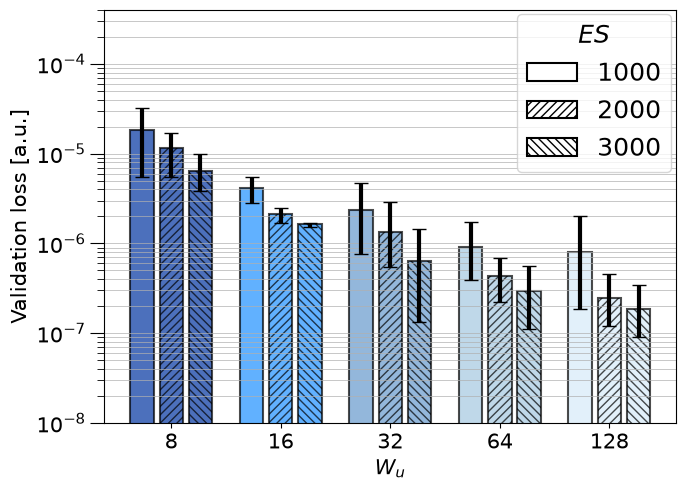

SORTED ['8', '16', '32', '64', '128']


/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_loss_running_min.py:468: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS6/plot_a2.png


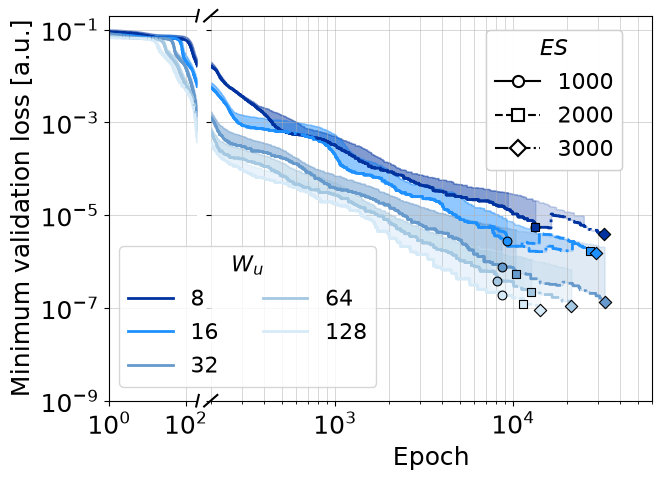

/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_mse_running_min.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS6/plot_a3.png


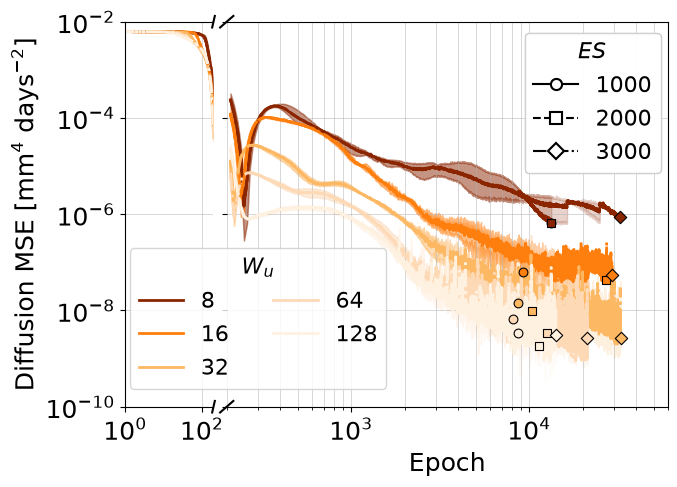

Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS6/plot_a4_diffusion_group_1_model0.png


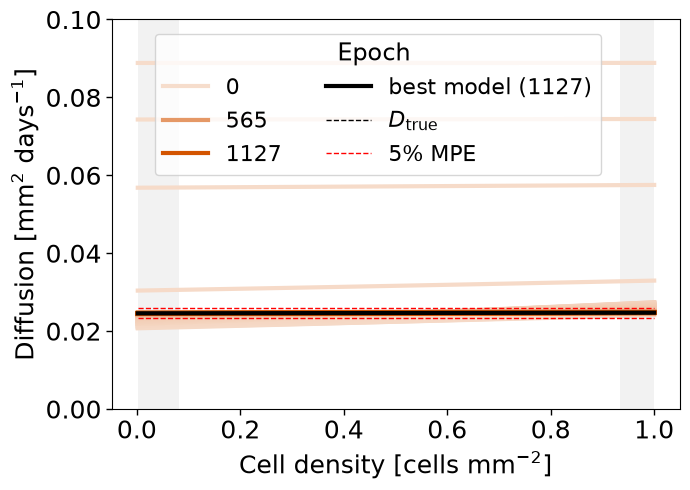

Saved diffusion plot for group_1, model_index=0, y_lim=(0, 0.1): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS6/plot_a4_diffusion_group_1_model0.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS6/plot_a5_diffusion_group_1_model0.png


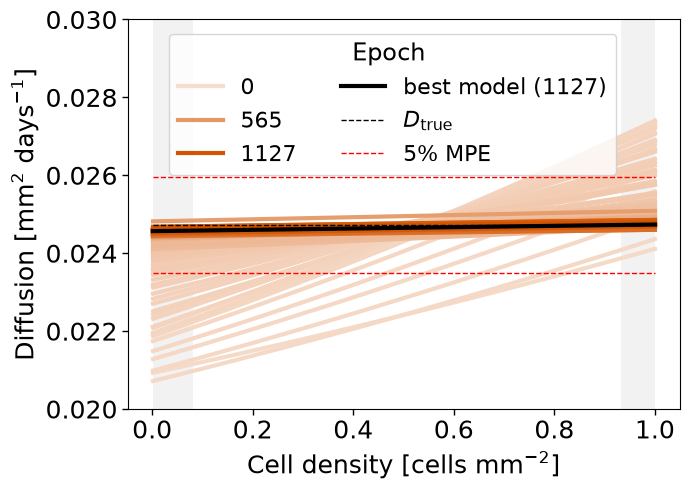

Saved diffusion plot for group_1, model_index=0, y_lim=(0.02, 0.03): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS6/plot_a5_diffusion_group_1_model0.png
Generating Figure 4 panels for activation=tanh
All x-axis labels found (ordered): ['8', '16', '32', '64', '128']
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS6/plot_b1.png


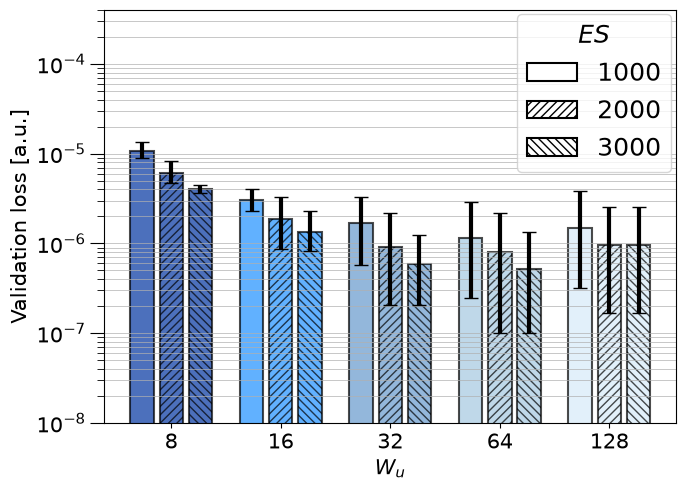

SORTED ['8', '16', '32', '64', '128']


/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_loss_running_min.py:468: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS6/plot_b2.png


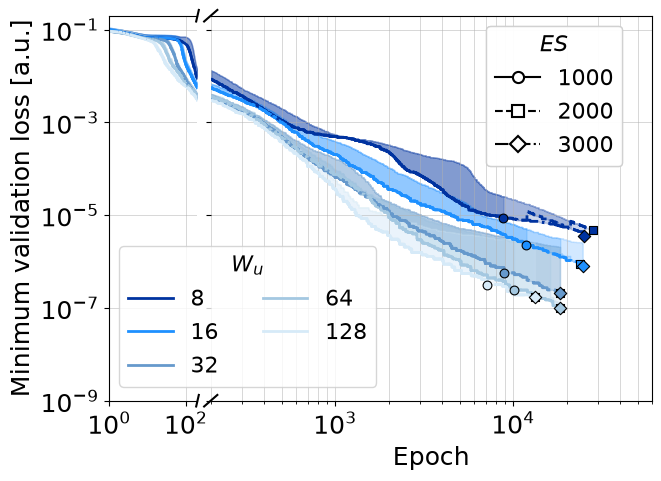

/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_mse_running_min.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS6/plot_b3.png


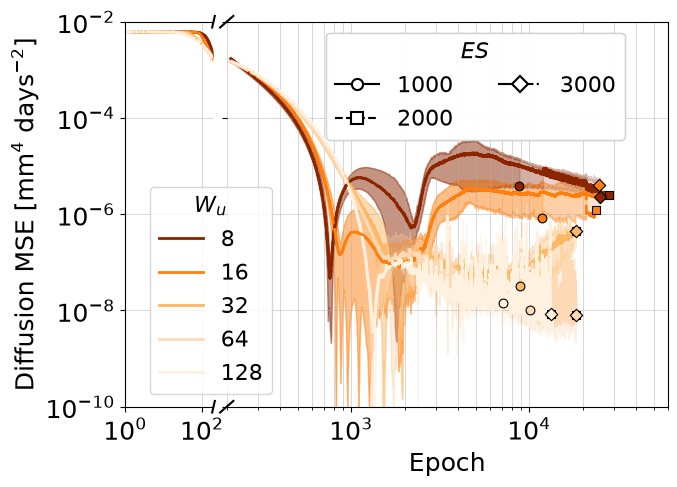

Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS6/plot_b4_diffusion_group_1_model0.png


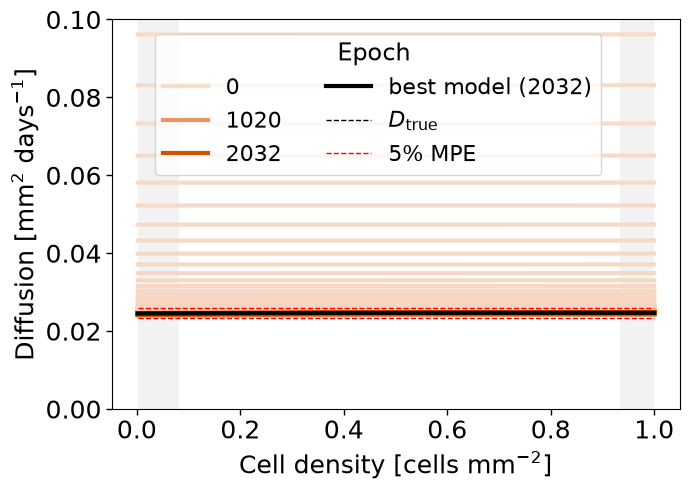

Saved diffusion plot for group_1, model_index=0, y_lim=(0, 0.1): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS6/plot_b4_diffusion_group_1_model0.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS6/plot_b5_diffusion_group_1_model0.png


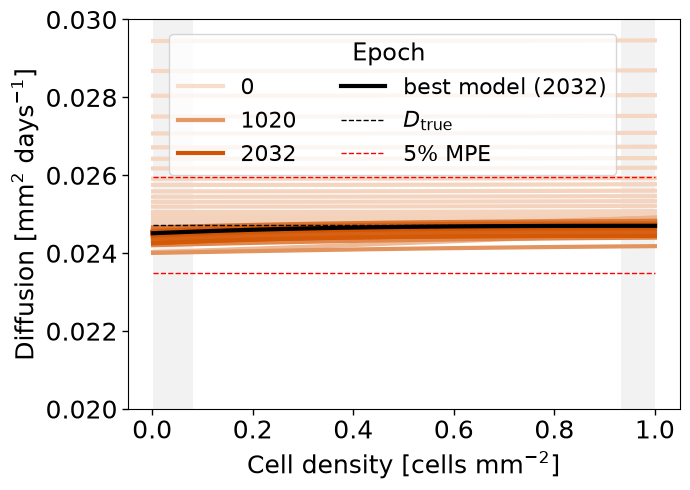

Saved diffusion plot for group_1, model_index=0, y_lim=(0.02, 0.03): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS6/plot_b5_diffusion_group_1_model0.png
Generating Figure 4 panels for activation=sigmoid
All x-axis labels found (ordered): ['8', '16', '32', '64', '128']
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS6/plot_c1.png


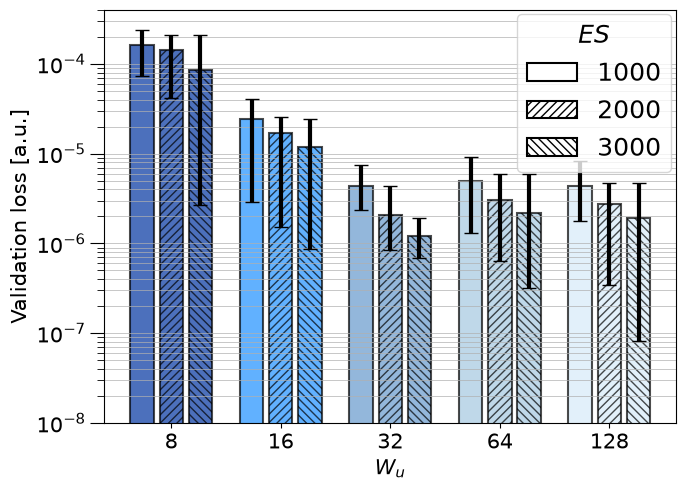

SORTED ['8', '16', '32', '64', '128']


/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_loss_running_min.py:468: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS6/plot_c2.png


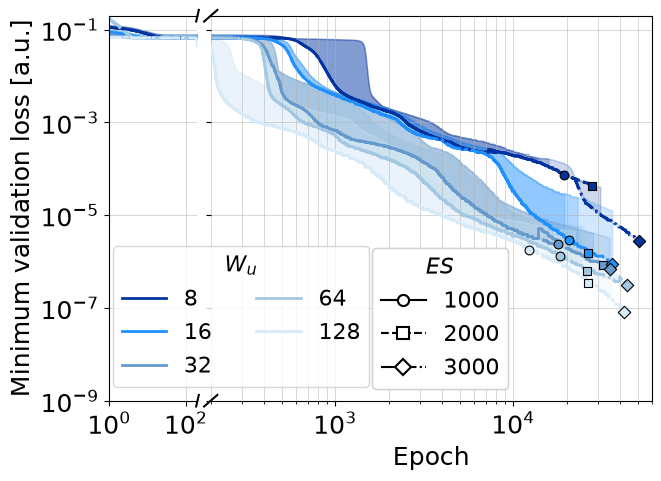

/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_mse_running_min.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS6/plot_c3.png


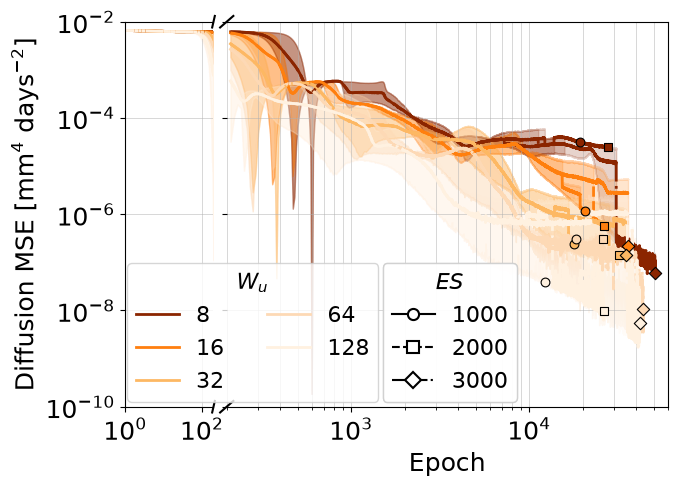

Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS6/plot_c4_diffusion_group_1_model0.png


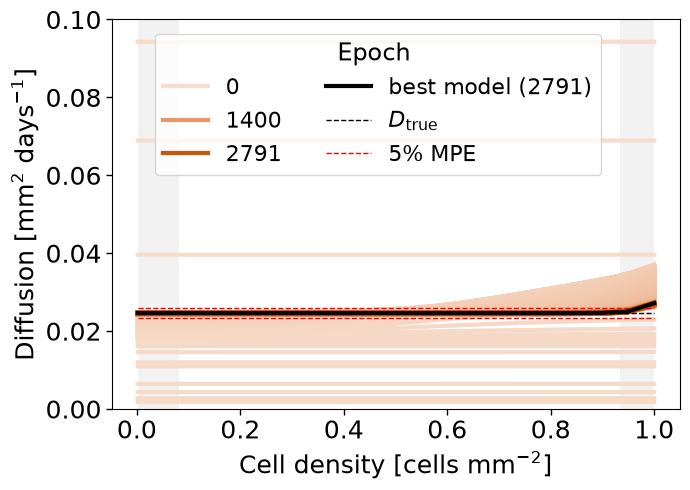

Saved diffusion plot for group_1, model_index=0, y_lim=(0, 0.1): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS6/plot_c4_diffusion_group_1_model0.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS6/plot_c5_diffusion_group_1_model0.png


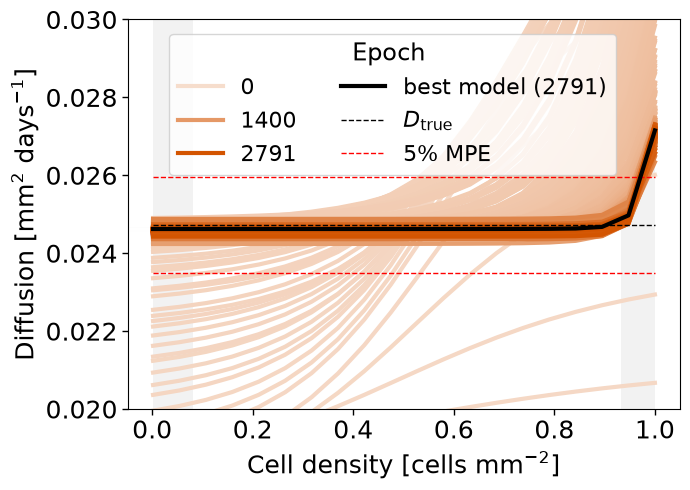

Saved diffusion plot for group_1, model_index=0, y_lim=(0.02, 0.03): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS6/plot_c5_diffusion_group_1_model0.png


In [8]:
def build_activation_plot_views(activation_label):
    run_state = activation_run_states[activation_label]
    activation_config = run_state["activation_config"]
    models_by_es = activation_models_by_name[activation_label]
    selected_D_NN = None if activation_config["perfectPDE"] else activation_config["selectedDSize"]
    selected_ES = activation_config["selectedES"]

    if selected_ES not in models_by_es:
        raise KeyError(f"No models were loaded for binnES={selected_ES} and activation={activation_label}.")
    if selected_D_NN not in models_by_es[selected_ES]:
        raise KeyError(
            f"No models were loaded for binnDsize={selected_D_NN} at binnES={selected_ES} "
            f"and activation={activation_label}."
        )

    models_for_selected_setting = models_by_es[selected_ES][selected_D_NN]
    models_by_es_for_selected_d = model_list_by_es_for_d(
        models_by_es,
        activation_config,
        selected_D_NN,
    )

    diffusion_es = activation_config["diffusionAcrossEpochsES"]
    diffusion_u_size = activation_config["diffusionAcrossEpochsUSize"]
    if diffusion_es not in models_by_es:
        raise KeyError(
            f"No models were loaded for binnES={diffusion_es} and activation={activation_label}."
        )
    if selected_D_NN not in models_by_es[diffusion_es]:
        raise KeyError(
            f"No diffusion-across-epochs models were loaded for binnDsize={selected_D_NN} "
            f"at binnES={diffusion_es} and activation={activation_label}."
        )
    if diffusion_u_size not in models_by_es[diffusion_es][selected_D_NN]:
        raise KeyError(
            f"No diffusion-across-epochs models were loaded for binnUsize={diffusion_u_size} "
            f"at binnES={diffusion_es}, binnDsize={selected_D_NN}, activation={activation_label}."
        )

    plot_params_val = plot_params_from_models(models_for_selected_setting, BLUE_COLORS)
    plot_params_diff = plot_params_from_models(models_for_selected_setting, D_COLORS)

    return {
        "activation_label": activation_label,
        "activation_config": activation_config,
        "selected_D_NN": selected_D_NN,
        "models_by_es": models_by_es,
        "models_for_selected_setting": models_for_selected_setting,
        "models_by_es_for_selected_d": models_by_es_for_selected_d,
        "diffusion_models": models_by_es[diffusion_es][selected_D_NN][diffusion_u_size],
        "plot_params_val": plot_params_val,
        "plot_params_diff": plot_params_diff,
        "output_dirs": activation_output_dirs(activation_label),
        "output_prefix": activation_output_prefix(activation_label),
    }


def build_activation_plot_settings(output_dirs, output_prefix, activation_legend_settings):
    return {
        "final_loss": {
            "name": str(output_dirs["root"] / f"plot_{output_prefix}1.png"),
            "bbox_to_anchor": (0.7, 1.02),
            "y_label": "Validation loss [a.u.]",
            "legend_size": LEGEND_SIZE,
            "legend_ncols":1,
            "legend_title": "$ES$",
            "x_label": r"$W_u$",
            "figsize": figsize,
            "ylim": (1e-8, 4e-4)
        },
        "data_loss": {
            "name": str(output_dirs["root"] / f"plot_{output_prefix}2.png"),
            "fill": True,
            "grid": True,
            "line_width": 2,
            "legend": activation_legend_settings["data_loss"],
            "xaxis": xaxis,
            "fontsizes": AXIS_FONTSIZES,
            "figsize": figsize,
            "ylabel": "Minimum validation loss [a.u.]",
            "y_lim": (1e-9, 0.2),
        },
        "diffusion_mse": {
            "name": str(output_dirs["root"] / f"plot_{output_prefix}3.png"),
            "fill": True,
            "line_width": 2,
            "grid": True,
            "legend": activation_legend_settings["diffusion_mse"],
            "xaxis": xaxis,
            "fontsizes": AXIS_FONTSIZES,
            "figsize": figsize,
            "ylim": (1e-10, 1e-2),
        },
        "diffusion_across_epochs": [
            {
                "name": str(output_dirs["root"] / f"plot_{output_prefix}4.png"),
                "fill": True,
                "line_width": 2,
                "legend": activation_legend_settings["diffusion_across_epochs"],
                "xaxis": xaxis,
                "line_lengths": {"hlength": 7.5e3, "vlength_factor": 2},
                "line_widths_on_axis": {"hwidth": 2, "vwidth": 2},
                "fontsizes": AXIS_FONTSIZES,
                "figsize": figsize,
                "y_lim": (0, 0.1),
                "mpe": 5,
                "epoch_step": 5,
            },
            {
                "name": str(output_dirs["root"] / f"plot_{output_prefix}5.png"),
                "fill": True,
                "line_width": 2,
                "legend": activation_legend_settings["diffusion_across_epochs"],
                "xaxis": xaxis,
                "line_lengths": {"hlength": 7.5e3, "vlength_factor": 2},
                "line_widths_on_axis": {"hwidth": 2, "vwidth": 2},
                "fontsizes": AXIS_FONTSIZES,
                "figsize": figsize,
                "y_lim": (0.02, 0.03),
                "mpe": 5,
                "epoch_step": 5,
            },
        ],
    }





def run_activation_figure_panels(views, settings):
    activation_config = views["activation_config"]

    plot_final_loss_lst(
        views["models_by_es_for_selected_d"],
        plot_params=views["plot_params_val"],
        label_list=[f"{ES}" for ES in activation_config["binnESList"]],
        **settings["final_loss"],
        grid=True,
        grid_alpha=1
    )

    plot_running_min_loss_component_broken_x_log_lst(
        models_dics_list=views["models_by_es_for_selected_d"],
        plot_params=views["plot_params_val"],
        plot_settings=settings["data_loss"],
        loss_attr="val_loss_list",
    )

    plot_running_min_MSE_diff_loss_broken_x_log_lst(
        models_dics_list=views["models_by_es_for_selected_d"],
        plot_params=views["plot_params_diff"],
        plot_settings=settings["diffusion_mse"],
    )

    for diffusion_plot_settings in settings["diffusion_across_epochs"]:
        plot_diffusion_across_epochs(
            overwrite=True,
            models_dics_list=[views["diffusion_models"]],
            plot_params=views["plot_params_diff"],
            plot_settings=diffusion_plot_settings,
        )


activation_legend_settings = {
    "silu": {
        "data_loss": {
            "panel": 2,
            "loc": (0.4, 0.43),
            "loc_upd": (0.6, 0.57),
            "fontsize": 16,
            "ncols": 2,
        },
        "diffusion_mse": {
            "panel": 2,
            "loc": (-0.245, 0.44),
            "loc_upd": (0.65,1),
            "fontsize": 16,
            "ncols": 2,
        },
        "diffusion_across_epochs": {
            "panel": 2,
            "loc": (0.075, 0.6),
            "loc_upd": (1, 1),
            "fontsize": 16,
            "ncols": 2,
        },
    },
    "tanh": {
        "data_loss": {
            "panel": 2,
            "loc": (0.4, 0.43),
            "loc_upd": (0.6, 0.58),
            "fontsize": 16,
            "ncols": 2,
        },
        "diffusion_mse": {
            "panel": 2,
            "loc": (-0.2, 0.6),
            "loc_upd": (0.2, 1),
            "fontsize": 16,
            "ncols": 1,
            "marker_ncols": 2,
        },
        "diffusion_across_epochs": {
            "panel": 2,
            "loc": (0.075, 0.6),
            "loc_upd": (1, 1),
            "fontsize": 16,
            "ncols": 2,
        },
    },
    "sigmoid": {
        "data_loss": {
            "panel": 2,
            "loc": (0.385, 0.43),
            "loc_upd": (0.7, 0.425),
            "fontsize": 16,
            "ncols": 2,
        },
        "diffusion_mse": {
            "panel": 2,
            "loc": (-0.25, 0.4),
            "loc_upd": (0.33, 0.4),
            "fontsize": 15.5,
            "ncols": 2,
            "marker_ncols": 1,
        },
        "diffusion_across_epochs": {
            "panel": 2,
            "loc": (0.075, 0.6),
            "loc_upd": (1, 1),
            "fontsize": 16,
            "ncols": 2,
        },
    },
}


for activation_label in ACTIVATION_SWEEP_CONFIG["activationLabels"]:
    print(f"Generating Figure 4 panels for activation={activation_label}")

    activation_plot_views = build_activation_plot_views(activation_label)

    activation_plot_settings = build_activation_plot_settings(
        output_dirs=activation_plot_views["output_dirs"],
        output_prefix=activation_plot_views["output_prefix"],
        activation_legend_settings=activation_legend_settings[activation_label],
    )

    run_activation_figure_panels(
        activation_plot_views,
        activation_plot_settings,
    )
    

## References

J. H. Lagergren et al. "Biologically-informed neural networks guide mechanistic modeling from sparse experimental data". In: *PLoS Comput Biol* 16.12 (2020), e1008462. DOI: [10.1371/journal.pcbi.1008462](https://doi.org/10.1371/journal.pcbi.1008462).
